# Interesting anomalies from clustering

In [1]:
import joblib
import os
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

from astroExplain.spectra import clustering
from sdss.metadata import MetaData
from anomaly.utils import specobjid_to_idx
meta = MetaData()

# Custom functions

## Top ranked anomalies

In [2]:
def get_sdss_spec_img(
    specobjid, ra, dec, fname_prefix, save_to
    ):
    """Download sdss image and spectrum"""

    meta.download_sdss_spectrum_image(
        specobjid=specobjid,
        save_to=save_to,
        image_format="jpeg",
        fname_prefix=fname_prefix
    )

    meta.get_sdss_image(
        specobjid,
        coordinates= (ra, dec),
        save_to=save_to,
        image_format="jpeg",
        fname_prefix=fname_prefix
    )

def obj_id_top_ranked_per_cluster(
    cluster_df,
    donwload_images=True,
    save_photometry_to= "./",
    n_top_ranked=20,
):

    n_anomalies_in_cluster = cluster_df.shape[0]
    print(f"Number of anomalies in cluster: {n_anomalies_in_cluster}")

    objd_id_dict = {}

    for anomaly_rank in range(0, n_anomalies_in_cluster):

        if anomaly_rank == n_top_ranked:
            break

        fname_prefix = f"rank_{anomaly_rank + 1:02d}"
        anomaly_idx = n_anomalies_in_cluster - 1 - anomaly_rank
        specobjid = cluster_df.index[anomaly_idx]

        objd_id_dict[anomaly_rank] = specobjid

        if donwload_images is True:
            ra, dec = cluster_df[['ra', 'dec']].loc[specobjid].values
            get_sdss_spec_img(
                specobjid,
                ra, dec,
                save_to=save_photometry_to,
                fname_prefix=fname_prefix
            )
    return objd_id_dict

## Plot spec with thumbnails and lines

In [3]:
GALAXY_LINES_NM = {
    'OII': {'name': 'OII', 'line_wave': 372.6},
    'H_delta': {'name': r'H$\delta$', 'line_wave': 410.2},
    'H_gamma': {'name': r'H$\gamma$', 'line_wave': 434.0},
    'H_beta': {'name': r'H$\beta$', 'line_wave': 486.1},
    'OIII': {'name': 'OIII', 'line_wave': 500.7},
    'H_alpha': {'name': r'H$\alpha$', 'line_wave': 656.3},
    'SII': {'name': 'SII', 'line_wave': 671.6},
    # 'SII': 673.0
}

def spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=0.3,
    indicator_height=0.5,
    indicator_color='royalblue',
    indicator_label_color='black',
    width_height_image=1
):

    fig, ax = plt.subplots()

    ax.plot(wave, spec, color='black')

    # Add line indicators and labels
    for line_name, value_dict in GALAXY_LINES_NM.items():

        line_wave = value_dict['line_wave']
        # Find the flux value of the spectrum at the line's wavelength
        # get small neigborhood among line_wave, get max flux there
        # and set as line_flux
        line_flux = np.max(
            spec[(wave > line_wave - delta) & (wave < line_wave + delta)]
        )

        # Define the vertical length of the indicator line
        # Plot the vertical line indicator
        ax.plot(
            [line_wave, line_wave], 
            [line_flux + indicator_starts, line_flux + indicator_height], 
            color=indicator_color, lw=1.5
        )
        
        # doubles manual setup
        if line_name == 'OIII':
            ax.plot(
                [495.9, 495.9], 
                [line_flux + indicator_starts, line_flux + indicator_height], 
                color=indicator_color, lw=1.5
        )

        if line_name == 'H_alpha':
            # NII 1st
            ax.plot(
                [654.8, 654.8], 
                [line_flux + 0.2, line_flux + indicator_height - 0.1], 
                color=indicator_color, lw=1.5
            )
            ax.text(
                646.3, 
                line_flux + indicator_height * 0.9, 
                'NII',
                ha='center', va='bottom', 
                fontsize=10, rotation=90, 
                color=indicator_label_color
            )

            # NII 2nd
            ax.plot(
                [658.3, 658.3], 
                [line_flux + 0.2, line_flux + indicator_height - 0.1], 
                color=indicator_color, lw=1.5
            )

            ax.text(
                666.3, 
                line_flux + indicator_height * 0.9, 
                'NII',
                ha='center', va='bottom', 
                fontsize=10, rotation=90, 
                color=indicator_label_color
            )

        if line_name == 'SII':
            ax.plot(
                [673, 673],
                [line_flux + indicator_starts, line_flux + indicator_height], 
                color=indicator_color, lw=1.5
            )

        clean_name = value_dict['name']

        ax.text(
            line_wave, 
            line_flux + indicator_height * 1.3 , 
            clean_name,
            ha='center', va='bottom', 
            fontsize=10, rotation=90, 
            color=indicator_label_color
        )


    # Create inset in top-right corner of figure
    axins = inset_axes(
        ax,
        width=width_height_image, height=width_height_image,
        bbox_to_anchor=(1, 1),
        bbox_transform=ax.transAxes,
        loc="upper right"
    )

    # Show image in the inset
    axins.imshow(photo_img)
    axins.axis('off')  # Hide axis around the image


    ax.set_xlabel('Wavelength [nm]')
    ax.set_ylabel('Median Normalized Flux')
    ax.set_xlim(np.min(wave)*0.975, np.max(wave)*1.025)
    ax.set_ylim(0, np.nanmax(spec)*1.2)

    return fig, ax, axins

# Directories

In [12]:
bin_id = "bin_03"
phd_dir = "/home/elom/phd/00_phd_code"
spectra_dir = f"{phd_dir}/spectra"
kmeans_model_dir = (
    f"{phd_dir}/clustering/{bin_id}/mse_noRel100/"
    "kmeans_top_1_percent_7_clusters_20250514144513_uniform_150_scale_0.9"
)
paper_dir = (
    "/home/elom/gdrive/career/portfolio/phd/"
    "00_paper_explain-me-why/submission"
)

# Data ingestion

In [9]:
spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)
idx_id_bin_03 = np.load(
    f"{spectra_dir}/{bin_id}/{bin_id}_index_specobjid.npy"
)
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
# convert from angstrom to nanometer
wave /= 10.0

# Load clusters and anomalies metadata

In [6]:
n_spec_bin_03 = 181_850
n_top_1_percent = int(n_spec_bin_03 * 0.01)
n_top_5_percent = int(n_spec_bin_03 * 0.05)
n_top_1_percent, n_top_5_percent
# n_top_1_percent = 180

(1818, 9092)

In [10]:
top_1_percent_df = pd.read_csv(
    f"{kmeans_model_dir}/"
    f"top_1_percent_anomalies.csv.gz",
    # compression="gzip",
    index_col="specobjid"
)

top_1_percent_df.shape,
top_1_percent_df.columns

Index(['mjd', 'plate', 'fiberid', 'run2d', 'ra', 'dec', 'z', 'zErr',
       'zWarning', 'class', 'subClass', 'z_noqso', 'zErr_noqso',
       'zWarning_noqso', 'targetType', 'programname', 'instrument', 'snMedian',
       'ABSSB', 'BROAD', 'ebv', 'score', 'cluster'],
      dtype='object')

# Cluster 1 Galaxies

In [11]:
# get IDs
cluster_id = 1

mask = top_1_percent_df["cluster"] == cluster_id
cluster_df = top_1_percent_df.loc[mask].copy()

save_to = !pwd
save_to = save_to[0]

obj_id_cluster_1_dict = obj_id_top_ranked_per_cluster(
    cluster_df,
    donwload_images=False,
    save_photometry_to=save_to,
    n_top_ranked=20,
)
# obj_id_cluster_1_dict

Number of anomalies in cluster: 617


## 1. **rank_01**

* **Reason for Selection:** Top-ranked anomaly and a prime example of a disturbed spiral.

* **Justification:** As the most anomalous object in this cluster, it's the natural first choice. Its morphology shows a bright, star-forming core with asymmetric and disturbed spiral arms, possibly due to a past or ongoing interaction. It perfectly represents the type of object this cluster identifies.

In [19]:
save_to = !pwd
save_cluster_1_to = f"{save_to[0]}/ranked_anomalies/cluster_1"

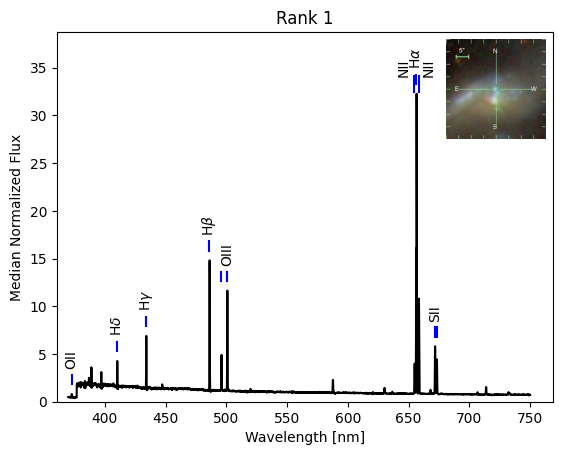

In [ ]:
rank = 1
obj_id = obj_id_cluster_1_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_1_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=1,
    indicator_height=2,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1

)
# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_1_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_1_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 2. **rank_05**
* **Reason for Selection:** A striking example of a highly disturbed, edge-on system.
* **Justification:** This galaxy is a dramatic edge-on disk that appears significantly warped and disrupted, likely the remnant of a merger. Its chaotic structure and bright, clumpy star-forming regions make it visually distinct and a clear anomaly.

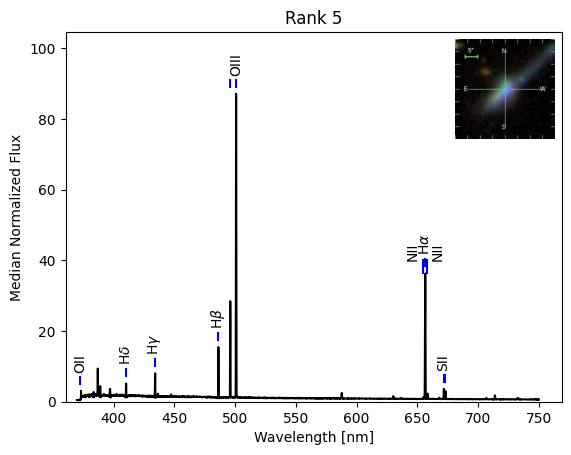

In [ ]:
rank = 5
obj_id = obj_id_cluster_1_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_1_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=2,
    indicator_height=4,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1

)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_1_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_1_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 3. **rank_18**
* **Reason for Selection:** The most unambiguous merger in the sample.
* **Justification:** This system is a visually spectacular merger-in-progress. It features two bright nuclei or massive star-forming clumps within a common, disturbed envelope of stars and gas. It's a "wow" object that powerfully demonstrates the pipeline's ability to find physically significant events.

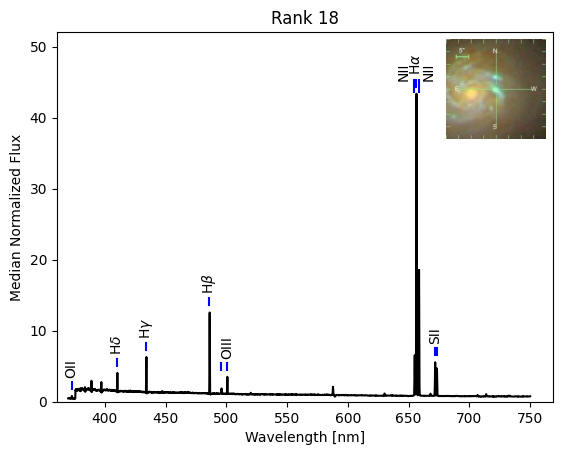

In [ ]:
rank = 18
obj_id = obj_id_cluster_1_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_1_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=1,
    indicator_height=2,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1

)
# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_1_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_1_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 4. **rank_02**
* **Reason for Selection:** A representative clumpy, edge-on starburst disk.
* **Justification:** While less disturbed than rank_05, this galaxy is a great example of an edge-on disk galaxy undergoing intense, clumpy star formation all along its plane. Its bright blue color and knotty texture are clear indicators of its anomalous nature.

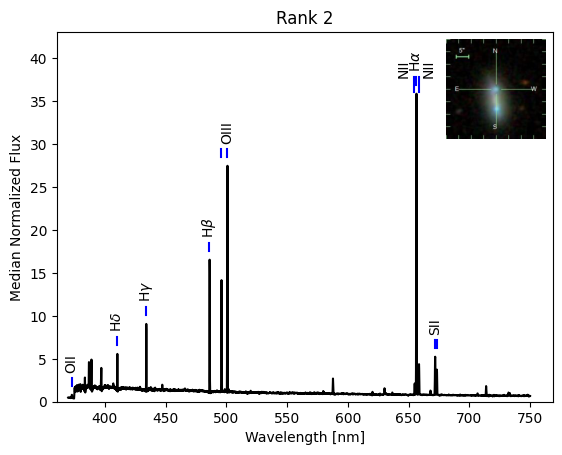

In [ ]:
rank = 2
obj_id = obj_id_cluster_1_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_1_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=1,
    indicator_height=2,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1

)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_1_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_1_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## Summary

This set of six galaxies is a strong choice because it's not just the six most anomalous, but a **diverse sample** that highlights different physical phenomena: a disturbed spiral, a compact starburst, a merger remnant, an interacting pair, an active merger, and a clumpy disk. This effectively showcases the range of "interesting" objects your method is capable of finding within a single cluster. 👍

# Cluster 2 Galaxies

From clustering analysis this cluster is expected to be more morphologically diverse, with a mix of spirals and compact galaxies, some of which appear inclined or edge-on.

This selection focuses on showcasing the various types of gravitational interactions and resulting morphologies that characterize the anomalies in this cluster.

In [20]:
# get IDs
cluster_id = 2

mask = top_1_percent_df["cluster"] == cluster_id
cluster_df = top_1_percent_df.loc[mask].copy()



save_to = !pwd
save_to = save_to[0]

obj_id_cluster_2_dict = obj_id_top_ranked_per_cluster(
    cluster_df,
    donwload_images=False,
    save_photometry_to=f"{save_to}/ranked_anomalies/cluster_2_photometry",
    n_top_ranked=20,
)
# obj_id_cluster_2_dict

Number of anomalies in cluster: 287


In [21]:
save_to = !pwd
save_cluster_2_to = f"{save_to[0]}/ranked_anomalies/cluster_2"

## 1. **rank_01**

* **Reason for Selection:** Top-ranked example of a spiral with extremely clumpy star formation.

* **Justification:** This galaxy serves as a great baseline for the cluster. While it has a recognizable spiral structure, its arms are resolved into a series of exceptionally bright, blue knots, indicating widespread and intense bursts of star formation that make it anomalous.


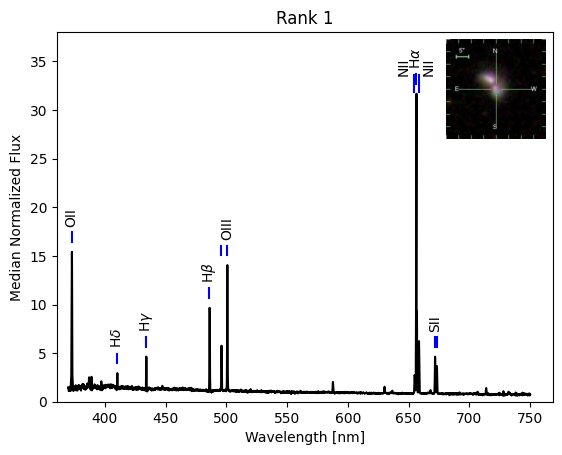

In [22]:
rank = 1
obj_id = obj_id_cluster_2_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_2_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=1,
    indicator_height=2,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1

)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_2_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_2_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 2. **rank_08**
* **Reason for Selection:** A striking, large-scale warped edge-on disk.

* **Justification:** This is a beautiful example of an edge-on spiral whose disk is significantly warped, bending upwards on the left and downwards on the right. This "S"-shape is a tell-tale sign of a past gravitational interaction and represents a more subtle, yet clearly anomalous, morphology.

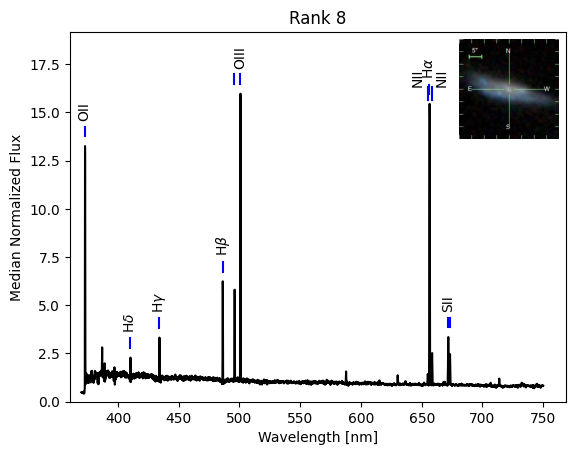

In [23]:
rank = 8
obj_id = obj_id_cluster_2_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_2_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=0.5,
    indicator_height=1,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1

)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_2_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_2_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 3. **rank_11**
* **Reason for Selection:** A chaotic "train wreck" system indicative of a major merger.

* **Justification:** This object is a complete mess of tidal features, shells, and bright blue star-forming clumps, with no discernible regular structure. It is a prime candidate for an advanced-stage merger of two or more galaxies, showcasing a more violent and chaotic aspect of galaxy evolution.

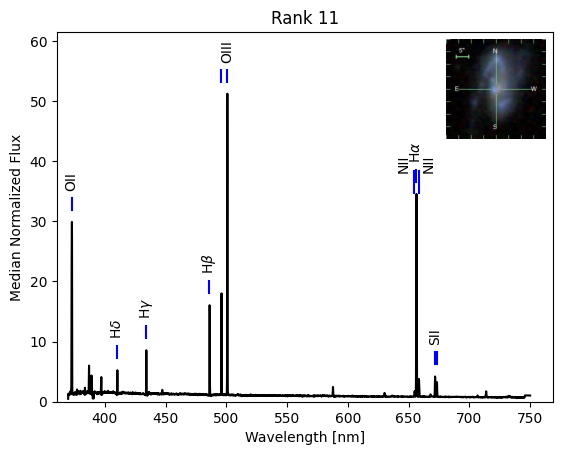

In [24]:
rank = 11
obj_id = obj_id_cluster_2_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_2_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=2,
    indicator_height=4,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1

)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_2_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_2_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 4. **rank_14**
* **Reason for Selection:** A clear post-merger system with prominent tidal tails.
* **Justification:** The central body of this galaxy is disturbed and bursting with star formation, but the most compelling features are the two faint tidal tails extending in opposite directions. These tails are classic, long-lived signatures of a recent merger event.

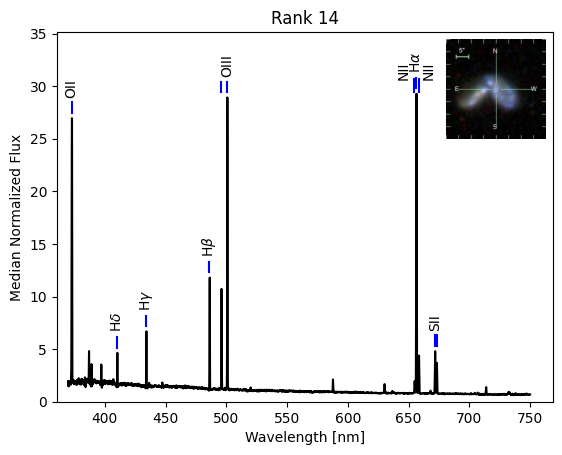

In [25]:
rank = 14
obj_id = obj_id_cluster_2_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_2_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=0.5,
    indicator_height=1.5,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1

)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_2_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_2_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 5. **rank_07**
* **Reason for Selection:** Asymmetric "tadpole" morphology from a likely minor merger.
* **Justification:** This galaxy is highly asymmetric, with a bright, compact "head" and a faint, elongated, linear "tail." This "tadpole" morphology is often the result of a smaller galaxy being accreted by a larger one and adds yet another distinct type of interaction-driven shape to our sample.


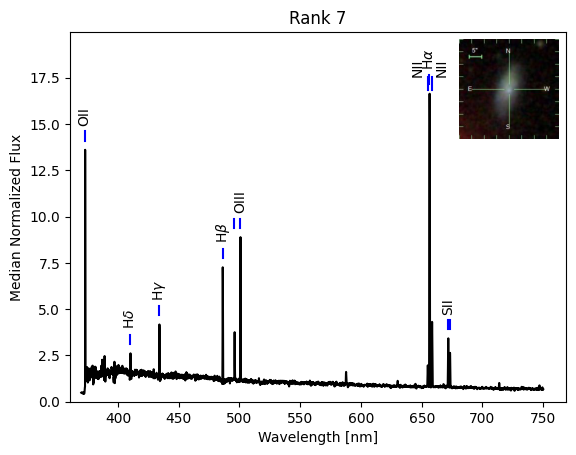

In [167]:
rank = 7
obj_id = obj_id_cluster_2_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_2_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=0.5,
    indicator_height=1.,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1

)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_2_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{save_cluster_2_to}/rank_{rank:02}_spec_photo.jpeg",
    bbox_inches='tight'
)

## Summary

This collection beautifully illustrates the dominant theme of **Cluster 2**: galaxies whose anomalous spectral features are linked to morphological disturbances from gravitational interactions. You have examples spanning the entire merger sequence: an early interaction (`rank_05`), a warped disk from a past encounter (`rank_08`), a chaotic ongoing merger (`rank_11`), a post-merger with tidal tails (`rank_14`), and a tadpole from a minor merger (`rank_07`). This is a very compelling and diverse set.

# Galaxies from Cluster 3

From cluster analysis, this cluster isolates the most extreme, low-metallicity emission-line galaxies, which often have compact, blue morphologies similar to "Green Pea" analogs. The provided images strongly support this, showing a remarkable collection of intensely star-forming and often disturbed systems.

This selection highlights the key features of Cluster 3: compact, high-surface-brightness cores, signs of mergers, and intense, blue star formation.


In [26]:
# get IDs
cluster_id = 3

mask = top_1_percent_df["cluster"] == cluster_id
cluster_df = top_1_percent_df.loc[mask].copy()



save_to = !pwd
save_to = save_to[0]

obj_id_cluster_3_dict = obj_id_top_ranked_per_cluster(
    cluster_df,
    donwload_images=False,
    save_photometry_to=save_to,
    n_top_ranked=20,
)
# obj_id_cluster_3_dict

Number of anomalies in cluster: 340


In [27]:
save_to = !pwd
save_cluster_3_to = f"{save_to[0]}/ranked_anomalies/cluster_3"

## 1. **rank_01**
* **Reason for Selection:** Top-ranked object that combines a compact core with merger features.

* **Justification:** This galaxy is the quintessential object for this cluster. It has an exceptionally bright and compact blue core, consistent with an extreme starburst, while also displaying faint, wispy tidal features in its outer regions. It perfectly illustrates that these powerful events are often linked to gravitational disturbances.

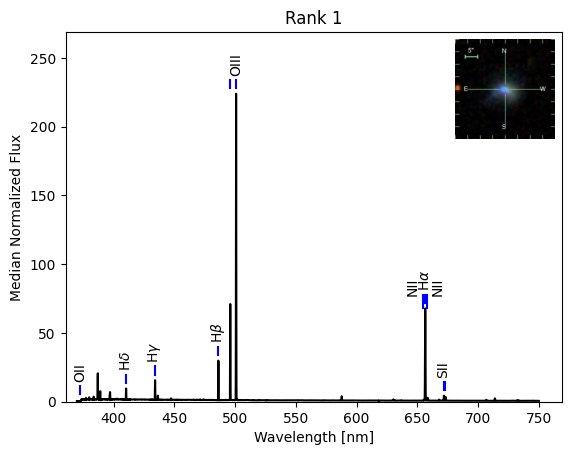

In [28]:
rank = 1
obj_id = obj_id_cluster_3_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_3_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=4,
    indicator_height=10.,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1

)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_3_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_3_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 2. **rank_05**

* **Reason for Selection:** The archetypal "Green Pea" analog in the sample.

* **Justification:** This object is extremely compact, intensely blue, and has a very high surface brightness, making it appear almost star-like. Its morphology is a textbook match for the "Green Pea" galaxies your paper references, representing the most extreme compact starbursts.

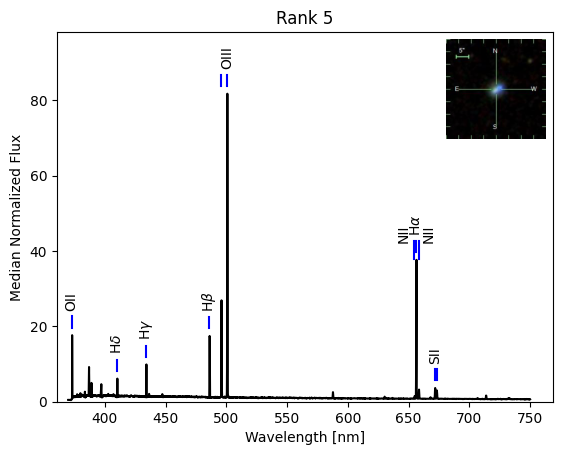

In [29]:
rank = 5
obj_id = obj_id_cluster_3_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_3_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=2,
    indicator_height=5.,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1

)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_3_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_3_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 3. **rank_09**
* **Reason for Selection:** A spectacular example of a chaotic, merger-driven starburst.

* **Justification:** This is a clear "train wreck" merger. The entire system is a messy collection of bright blue star-forming knots and extended tidal arms. It provides powerful visual evidence of a violent merger triggering the extreme spectral features characteristic of this cluster.

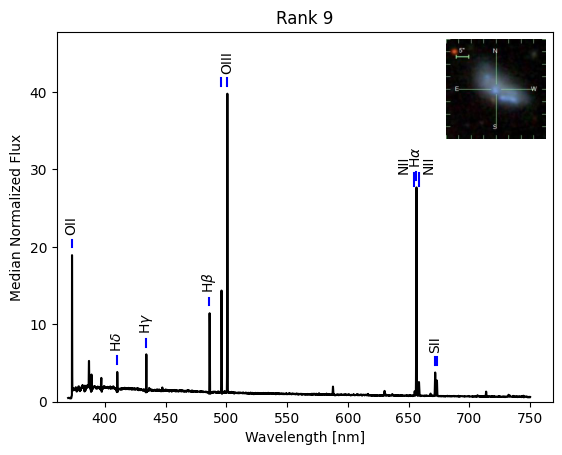

In [30]:
rank = 9
obj_id = obj_id_cluster_3_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_3_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=1,
    indicator_height=2,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1

)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_3_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_3_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 4. **rank_10**

* **Reason for Selection:** A morphologically peculiar edge-on system with an offset starburst.

* **Justification:** This is a highly unusual galaxy. While it has an edge-on disk, the most intense star formation is happening in a bright, detached clump at the very end of the disk, giving it a cometary or "head-tail" appearance. This unique morphology makes it a particularly interesting anomaly.

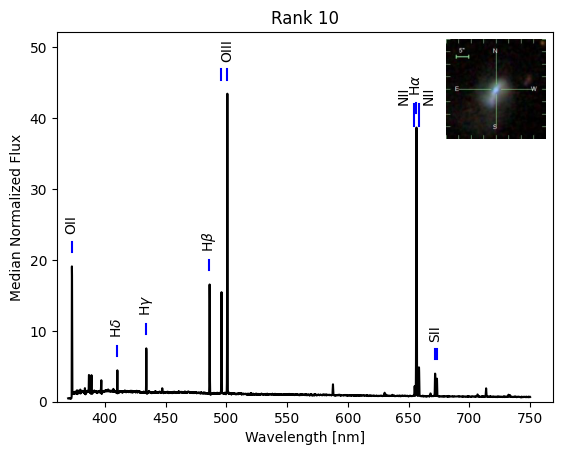

In [31]:
rank = 10
obj_id = obj_id_cluster_3_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_3_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=2,
    indicator_height=3.5,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1

)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_3_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{paper_dir}/cluster_3_rank_{rank:02}.pdf",
    bbox_inches='tight'
)

## 5. **rank_19**

* **Reason for Selection:** A compelling "double nucleus" system or close pair merger.

* **Justification:** This image shows two distinct, extremely blue, and compact cores embedded within a faint common envelope. This is a fantastic example of a merger in its final stages, where the two galactic nuclei are about to coalesce, likely fueling the extreme star formation in both components.

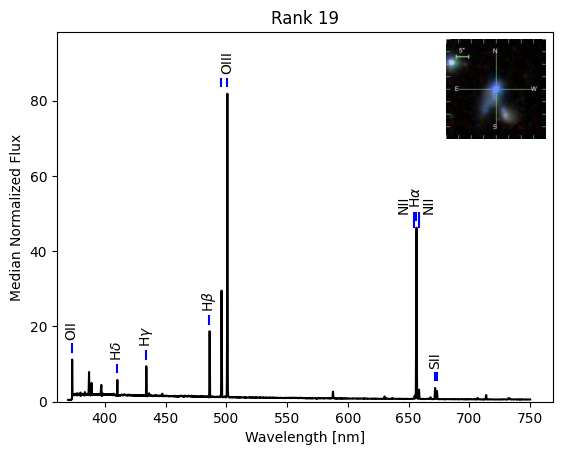

In [174]:
rank = 19
obj_id = obj_id_cluster_3_dict[rank-1]
idx_spec = specobjid_to_idx(obj_id, idx_id_bin_03)
spec = spectra[idx_spec]

working_directory = !pwd
working_directory = working_directory[0]
# Load the image
image_name = f'rank_{rank:02}_image_{obj_id}.jpeg'
image_dir = f"{working_directory}/ranked_anomalies/cluster_3_photometry"
photo_img = mpimg.imread(f"{image_dir}/{image_name}")

fig, ax, axins = spec_photo_thumbnail_line_indicators(
    wave, spec,
    photo_img,
    delta=1,
    indicator_starts=2,
    indicator_height=4,
    indicator_color='blue',
    indicator_label_color='black',
    width_height_image=1

)

# add title
ax.set_title(f"Rank {rank}")
# save figure
fig.savefig(
    f"{save_cluster_3_to}/rank_{rank:02}_spec_photo.pdf",
    bbox_inches='tight'
)
fig.savefig(
    f"{save_cluster_3_to}/rank_{rank:02}_spec_photo.jpeg",
    bbox_inches='tight'
)

## Summary

This set perfectly illustrates the physical nature of Cluster 3, showcasing classic "Green Pea" analogs, various stages of dramatic mergers, and other peculiar structures.